<a href="https://colab.research.google.com/github/nisaa783/practical-statistics-for-data-scientists_Anisa-Khasanah/blob/main/Chapter_4_Regression_and_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 4: Regression and Prediction

Regresi adalah salah satu teknik fundamental dalam *machine learning* dan statistik yang digunakan untuk memprediksi nilai numerik kontinu berdasarkan satu atau lebih variabel prediktor (fitur). Bab ini membahas cara kerja regresi linier, evaluasi model, serta penanganan variabel kategorikal dalam pemodelan prediktif.

---

## 1. Simple Linear Regression (Regresi Linier Sederhana)
* **Definisi:** Model statistik untuk memperkirakan hubungan antara satu variabel independen ($X$) dan satu variabel dependen kontinu ($Y$).
* **Persamaan Garis:**
  $$Y = \beta_0 + \beta_1 X + \epsilon$$
  Di mana $\beta_0$ adalah *intercept* (titik potong sumbu Y), $\beta_1$ adalah *slope* (kemiringan/koefisien regresi), dan $\epsilon$ adalah galat (*error*).
* **Ordinary Least Squares (OLS):** Metode yang digunakan untuk memperkirakan parameter $\beta_0$ dan $\beta_1$ dengan meminimalkan jumlah kuadrat sisaan (*sum of squared residuals*) antara nilai aktual dan nilai prediksi.

---

## 2. Multiple Linear Regression (Regresi Linier Berganda)
* **Definisi:** Perluasan dari regresi linier sederhana yang melibatkan dua atau lebih variabel prediktor ($X_1, X_2, \dots, X_p$) untuk memprediksi satu variabel target ($Y$).
* **Evaluasi Model:**
  * **RMSE (Root Mean Squared Error):** Mengukur rata-rata besarnya kesalahan prediksi dalam satuan yang sama dengan variabel target.
  * **R-Squared ($R^2$):** Menunjukkan persentase variasi dalam variabel target yang dapat dijelaskan oleh model regresi.

---

## 3. Penanganan Variabel Kategorikal dalam Regresi
Komputer dan algoritma regresi membutuhkan input berupa angka. Oleh karena itu, variabel kategorikal harus diubah menjadi format numerik:
* **One-Hot Encoding / Dummy Variables:** Mengubah variabel kategori dengan $k$ level menjadi $k-1$ variabel biner (0 atau 1) untuk menghindari masalah *multicollinearity* (trap dummy variable).
* **Factor Variables:** Representasi tingkat kategori dalam bentuk faktor statistik.

--- 5 Baris Pertama Dataset House Sales ---


,DocumentDate,SalePrice,PropertyID,PropertyType,ym,zhvi_px,zhvi_idx,AdjSalePrice,NbrLivingUnits,SqFtLot,...,Bathrooms,Bedrooms,BldgGrade,YrBuilt,YrRenovated,TrafficNoise,LandVal,ImpsVal,ZipCode,NewConstruction
1,2014-09-16,280000,1000102,Multiplex,2014-09-01,405100,0.930836,300805.0,2,9373,...,3.00,6,7,1991,0,0,70000,229000,98002,False
2,2006-06-16,1000000,1200013,Single Family,2006-06-01,404400,0.929228,1076162.0,1,20156,...,3.75,4,10,2005,0,0,203000,590000,98166,True
3,2007-01-29,745000,1200019,Single Family,2007-01-01,425600,0.977941,761805.0,1,26036,...,1.75,4,8,1947,0,0,183000,275000,98166,False
4,2008-02-25,425000,2800016,Single Family,2008-02-01,418400,0.961397,442065.0,1,8618,...,3.75,5,7,1966,0,0,104000,229000,98168,False
5,2013-03-29,240000,2800024,Single Family,2013-03-01,351600,0.807904,297065.0,1,8620,...,1.75,4,7,1948,0,0,104000,205000,98168,False



--- Ringkasan Model Regresi Sederhana ---
                            OLS Regression Results                            
Dep. Variable:           AdjSalePrice   R-squared:                       0.483
Model:                            OLS   Adj. R-squared:                  0.483
Method:                 Least Squares   F-statistic:                 2.121e+04
Date:                Sat, 03 Oct 2026   Prob (F-statistic):               0.00
Time:                        17:08:49   Log-Likelihood:            -3.1650e+05
No. Observations:               22687   AIC:                         6.330e+05
Df Residuals:                   22685   BIC:                         6.330e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Int

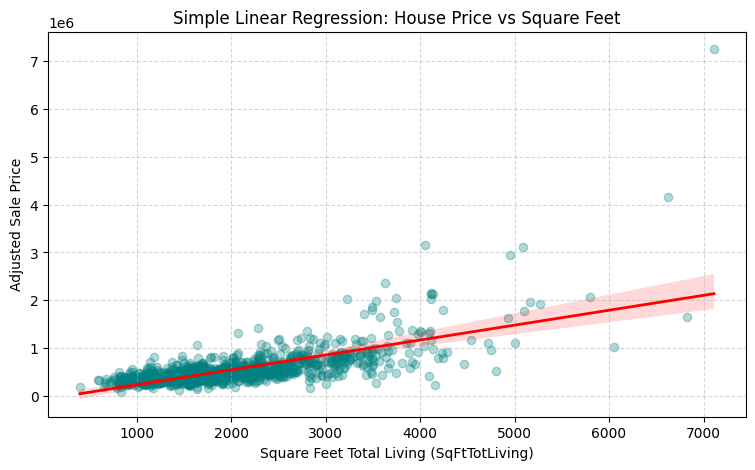

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf

# ==========================================
# 1. Menarik Dataset dengan Pemisah Tab (sep='\t')
# ==========================================
url = "https://raw.githubusercontent.com/gedeck/practical-statistics-for-data-scientists/master/data/house_sales.csv"
house = pd.read_csv(url, sep='\t')

print("--- 5 Baris Pertama Dataset House Sales ---")
display(house.head())

# ==========================================
# 2. Regresi Linier Sederhana (Simple Linear Regression)
# ==========================================
# Memprediksi harga rumah (AdjSalePrice) berdasarkan luas bangunan (SqFtTotLiving)
formula_simple = "AdjSalePrice ~ SqFtTotLiving"
model_simple = smf.ols(formula_simple, data=house).fit()

print("\n--- Ringkasan Model Regresi Sederhana ---")
print(model_simple.summary())

# ==========================================
# 3. Regresi Linier Berganda (Multiple Linear Regression)
# ==========================================
# Menambahkan prediktor lain: Luas Bangunan, Luas Tanah, Kamar Mandi, dan Kamar Tidur
formula_multi = "AdjSalePrice ~ SqFtTotLiving + SqFtLot + Bathrooms + Bedrooms"
model_multi = smf.ols(formula_multi, data=house).fit()

print("\n--- Ringkasan Model Regresi Berganda ---")
print(model_multi.summary())

# ==========================================
# 4. Visualisasi Hasil Regresi Sederhana
# ==========================================
plt.figure(figsize=(9, 5))
sns.regplot(
    data=house.sample(1000, random_state=42), # Mengambil sampel acak agar visualisasi lebih ringan
    x='SqFtTotLiving',
    y='AdjSalePrice',
    scatter_kws={'alpha': 0.3, 'color': 'teal'},
    line_kws={'color': 'red', 'linewidth': 2}
)
plt.title('Simple Linear Regression: House Price vs Square Feet')
plt.xlabel('Square Feet Total Living (SqFtTotLiving)')
plt.ylabel('Adjusted Sale Price')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()